### Importações

In [17]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split, learning_curve
import matplotlib.pyplot as plt
import time
import numpy as np

import seaborn as sns

sns.set(style="darkgrid")

In [8]:
# Caminhos para o dataset e dicionário
dataset_path = "../../Datasets/Telegram_Tratado_Rotulado_Revisado_Final.csv"
dic_path = "../../Dicionário/v2_SocialLIWC_formatado_ordenado.dic"

# Carrega o dataset
df = pd.read_csv(dataset_path)
df['text_content_anonymous'] = df['text_content_anonymous'].astype(str)

### Carrega o PrejudiceBR

In [9]:
# Função para carregar o dicionário
def carregar_dicionario_personalizado(dic_path):
    categorias = {}
    lexicon = {}
    dentro_das_categorias = False

    with open(dic_path, 'r', encoding='utf-8') as file:
        for linha in file:
            linha = linha.strip()
            
            # Detecta a seção de categorias delimitada por '%'
            if linha == '%':
                dentro_das_categorias = not dentro_das_categorias
                continue
            
            # Lê as categorias personalizadas
            if dentro_das_categorias:
                codigo, categoria = linha.split()
                categorias[codigo] = categoria
            else:
                # Lê as palavras e suas categorias
                partes = linha.split("\t")
                palavra = partes[0]
                categoria_ids = partes[1:]
                lexicon[palavra] = [categorias[codigo] for codigo in categoria_ids if codigo in categorias]
    
    return lexicon, list(categorias.values())

### Tokenizar e organizar as palavras como features

In [10]:
# Tokenização simples
def tokenize(text):
    tokens = []
    for match in re.finditer(r"\w+", text, re.UNICODE):
        tokens.append(match.group(0).lower())
    return tokens

# Função para incluir palavras do dicionário como colunas
def adicionar_palavras_como_features(df, lexicon):
    # Criar DataFrame temporário com todas as palavras inicializadas com 0
    new_columns = pd.DataFrame(0, index=df.index, columns=list(lexicon.keys()))
    
    # Concatenar com o DataFrame original de uma vez
    df = pd.concat([df, new_columns], axis=1)
    
    # Contar ocorrências de cada palavra no texto
    for i, texto in df['text_content_anonymous'].items():
        tokens = tokenize(texto)
        for token in tokens:
            if token in lexicon:
                df.at[i, token] += 1
                
    return df

### Configuração do baseline

In [11]:
# Carrega o dicionário
lexicon, category_names = carregar_dicionario_personalizado(dic_path)

# Adiciona palavras como features
df = adicionar_palavras_como_features(df, lexicon)

# Define as colunas de entrada (todas as palavras do dicionário) e o rótulo
X = df[list(lexicon.keys())]
y = df['preconceito']
total_features = X.shape[1] 

# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

### Modelos

In [6]:
# Modelos
models = [
    LogisticRegression(), BernoulliNB(), MultinomialNB(), LinearSVC(dual=False),
    KNeighborsClassifier(), RandomForestClassifier(),
    GradientBoostingClassifier(n_estimators=200), MLPClassifier(batch_size=64, max_iter=50, early_stopping=True)
]

### Avaliação

In [7]:
# Avaliação de modelos com validação cruzada e teste final
resultados = []

for model in models:
    start_time = time.time()
    
    # Validação Cruzada (métricas médias dos folds de validação)
    metodos_scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    cv_results = cross_validate(model, X_train, y_train, cv=5, scoring=metodos_scoring, return_train_score=True)
    
    # Treina o modelo no conjunto de treino completo
    model.fit(X_train, y_train)
    
    # Prevê no conjunto de teste (holdout)
    y_pred = model.predict(X_test)
    
    # Métricas no teste
    test_accuracy = accuracy_score(y_test, y_pred)
    test_precision = precision_score(y_test, y_pred)
    test_recall = recall_score(y_test, y_pred)
    test_f1 = f1_score(y_test, y_pred)
    
    # Calcula ROC AUC no teste (manuseia modelos sem predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    test_roc_auc = roc_auc_score(y_test, y_proba)
    
    end_time = time.time()
    
    # Compila resultados
    resultado = {
        'model': model.__class__.__name__,
        'execution_time': end_time - start_time,
        'total_features': total_features,
    }
    
    # Métricas de validação cruzada (média dos folds)
    for scoring in metodos_scoring:
        resultado[f'cv_{scoring}_avg'] = cv_results[f'test_{scoring}'].mean()
        resultado[f'cv_{scoring}_std'] = cv_results[f'test_{scoring}'].std()
    
    # Métricas no teste (holdout)
    resultado.update({
        'test_accuracy': test_accuracy,
        'test_precision': test_precision,
        'test_recall': test_recall,
        'test_f1': test_f1,
        'test_roc_auc': test_roc_auc
    })
    
    resultados.append(resultado)


In [8]:
# Exibe resultados formatados
df_resultados = pd.DataFrame(resultados)
cols_order = [
    'model', 'total_features', 'execution_time',
    'cv_accuracy_avg', 'test_accuracy',
    'cv_precision_avg', 'test_precision',
    'cv_recall_avg', 'test_recall',
    'cv_f1_avg', 'test_f1',
    'cv_roc_auc_avg', 'test_roc_auc'
]

print(df_resultados[cols_order].round(3))

                        model  total_features  execution_time  \
0          LogisticRegression             842           0.788   
1                 BernoulliNB             842           0.811   
2               MultinomialNB             842           0.540   
3                   LinearSVC             842           0.609   
4        KNeighborsClassifier             842           3.091   
5      RandomForestClassifier             842           4.755   
6  GradientBoostingClassifier             842           7.731   
7               MLPClassifier             842           6.556   

   cv_accuracy_avg  test_accuracy  cv_precision_avg  test_precision  \
0            0.743          0.743             0.837           0.809   
1            0.739          0.730             0.800           0.772   
2            0.741          0.735             0.800           0.776   
3            0.742          0.735             0.828           0.805   
4            0.695          0.717             0.741        

### Salva os resultados

In [9]:
# Salva as métricas no CSV
metrics_output_path = "dic_model_performance_metrics.csv"
df_resultados.to_csv(metrics_output_path, index=False)
print(f"Métricas salvas em: {metrics_output_path}")

# Salva o dataset processado
df.to_csv("telegram_processado.csv", index=False)

Métricas salvas em: dic_model_performance_metrics.csv


In [12]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def getTestMetrics(y_test, y_pred, y_prob=None, full_metrics=True, print_charts=False):
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    precision_neg = precision_score(y_test, y_pred, pos_label=0)
    recall = recall_score(y_test, y_pred)
    recall_neg = recall_score(y_test, y_pred, pos_label=0)
    f1 = f1_score(y_test, y_pred)
    f1_neg = 2 * (precision_neg * recall_neg) / (precision_neg + recall_neg)

    # Calcular o ROC AUC apenas se y_prob não for None
    if y_prob is not None:
        roc_auc = roc_auc_score(y_test, y_prob)
    else:
        roc_auc = None  # ou algum valor indicativo, como 0.0
    
    return (acc, precision, precision_neg, recall, recall_neg, f1, f1_neg, roc_auc)

Rodando experimento: ml-dic_842

 Resultados - MNB - dic_842
Acurácia:  0.745
Precisão:  0.782
Revocação: 0.680
F1:        0.727
ROC AUC:   0.812


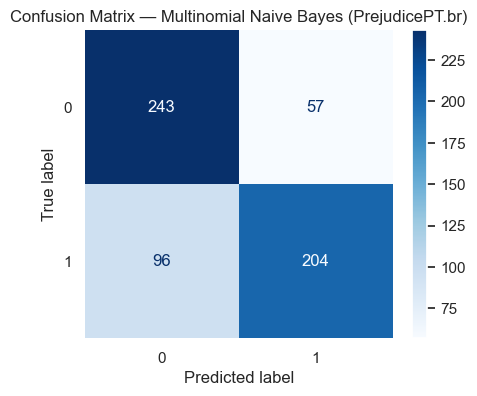

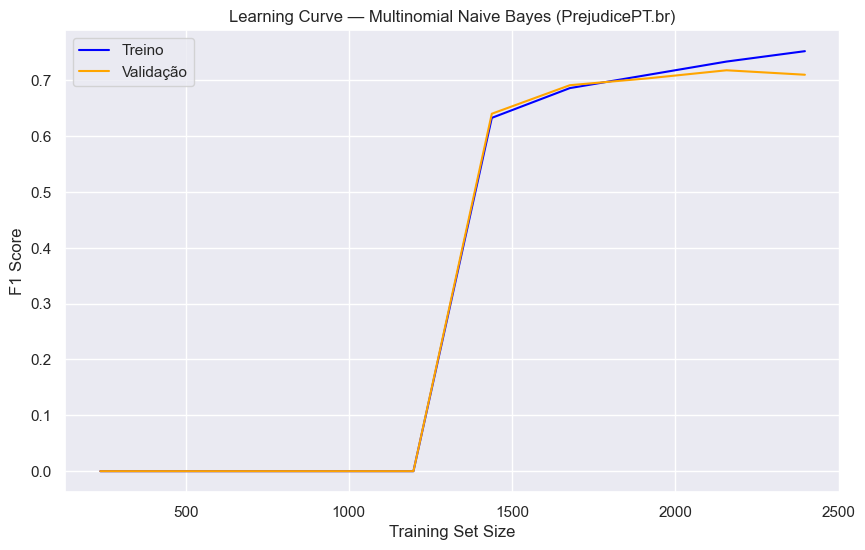

In [18]:
# === Executar apenas o experimento ml-dic ===
experiment = "ml-dic_842"
print(f"Rodando experimento: {experiment}")

# --- Remover duplicatas e tratar dados ---
df = df.drop_duplicates(subset=["text_content_anonymous"])
df["text_content_anonymous"] = df["text_content_anonymous"].fillna("").astype(str)



# Carrega o dicionário
lexicon, category_names = carregar_dicionario_personalizado(dic_path)

# Adiciona palavras como features
df = adicionar_palavras_como_features(df, lexicon)

# Define as colunas de entrada (todas as palavras do dicionário) e o rótulo
X = df[list(lexicon.keys())]
y = df['preconceito']
total_features = X.shape[1] 

# Divisão dos dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# --- Modelo Gradient Boosting ---
model = MultinomialNB()

# --- Treinamento ---
model.fit(X_train, y_train)

# --- Predições ---
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# --- Métricas ---
acc, prec_pos, prec_neg, rec_pos, rec_neg, f1_pos, f1_neg, roc_auc = getTestMetrics(
    y_test, y_pred, y_prob
)

print("\n Resultados - MNB - dic_842")
print(f"Acurácia:  {acc:.3f}")
print(f"Precisão:  {prec_pos:.3f}")
print(f"Revocação: {rec_pos:.3f}")
print(f"F1:        {f1_pos:.3f}")
print(f"ROC AUC:   {roc_auc:.3f}")

# === Matriz de Confusão ===
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["0", "1"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d", ax=ax)

# remover linhas e bordas
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(False)

plt.title("Confusion Matrix — Multinomial Naive Bayes (PrejudicePT.br)")
plt.savefig("matriz_confusao_mnb_dic_842_telegram.png", dpi=300, bbox_inches="tight")
plt.show()

# === Curva de Aprendizado ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_sizes, train_scores, val_scores = learning_curve(
    model, X, y,
    cv=cv, scoring="f1", n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)


plt.figure(figsize=(10, 6))
plt.title("Learning Curve — Multinomial Naive Bayes (PrejudicePT.br)")
plt.plot(train_sizes, train_mean, color="blue", label="Treino")
plt.plot(train_sizes, val_mean, color="orange", label="Validação")
plt.xlabel("Training Set Size")
plt.ylabel("F1 Score")
plt.legend(loc="best")
plt.grid(True)
plt.show()


